# VIETNAM'S ECONOMIC STRUCTURE IN ASEAN (2000-2023)


### 1. Theoretical Basis: Environmental Kuznets Curve (EKC)
**The Environmental Kuznets Curve (EKC)** is an economic hypothesis suggesting that environmental degradation increases in the early stages of economic development, but after reaching a certain income threshold (Turning Point), environmental quality begins to improve.


To determine where a country stands on this curve, we rely on the **Slope** of its development trajectory:
- **Phase 1 (Intensive phase):** The curve slopes upwards to the right. Increasing income means increasing pollution (Positive correlation).
- **Phase 2 (Turning point):** The curve begins to level off or slope downwards, indicating pollution saturation.
- **Phase 3 (Decoupling phase):** The curve slopes downwards to the left. The economy continues to grow while pollution significantly decreases.

### 2. Why choose the High Income group as a benchmark?
Including the **High Income** group in the chart is not just for data comparison but has strategic significance:
- **Establishing a "Gold Standard":** This group represents **Phase 3** of the EKC. They are proof that an economy can achieve massive industrial output while maintaining a clean environment.
- **Demonstrating Decoupling:** Showing the High Income group helps us clearly see the technological and institutional gap between Vietnam and the world, thereby determining the necessary roadmap.

### 3. Analysis Objectives
We will unpack the story of "Buying growth with the environment" through 3 questions:
1. **Question 1 (Structure):** Is Vietnam an "outlier" in terms of industrialization within ASEAN?
2. **Question 2 (Coupling):** At what phase is Vietnam's GDP dependence on Carbon emissions?
3. **Question 3 (Paradox):** Why does life expectancy continue to increase despite severe environmental degradation?

##CLEAN DATA

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_excel('../data.xlsx', sheet_name='Data')

year_cols = [col for col in df_raw.columns if '[YR' in str(col)]
rename_dict = {col: int(str(col).split(' ')[0]) for col in year_cols}
df_raw.rename(columns=rename_dict, inplace=True)
df_raw.replace('..', np.nan, inplace=True)

id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
df_melted = pd.melt(df_raw, id_vars=id_vars, value_vars=list(rename_dict.values()),
                    var_name='Year', value_name='Value')
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

indicators = {
    'NV.IND.TOTL.ZS': 'Ind_GDP',
    'EN.GHG.CO2.PC.CE.AR5': 'CO2_PC',
    'EN.ATM.PM25.MC.M3': 'PM25',
    'SP.DYN.LE00.IN': 'Life_Exp'
}
df_multi = df_melted.pivot_table(index=['Country Name', 'Year'], columns='Series Code', values='Value').reset_index()
df_multi.rename(columns=indicators, inplace=True)

df_multi['PM25'] = df_multi.groupby('Country Name')['PM25'].transform(lambda x: x.interpolate(limit_direction='both'))

asean_all = ['Viet Nam', 'Thailand', 'Indonesia', 'Philippines', 'Cambodia', 'Lao PDR', 'Myanmar', 'Singapore', 'Malaysia', 'Brunei Darussalam', 'Timor-Leste']
df_final = df_multi[df_multi['Country Name'].isin(asean_all + ['High income', 'Lower middle income'])]

### Question 1: Structural analysis of Vietnam's industrialization stage compared to ASEAN
- **Rationale for selection:** To determine whether Vietnam is an "outlier" in the region. While most ASEAN countries are shifting towards the service sector, Vietnam continues to maintain strong industrial growth momentum.
- **Metrics:** `NV.IND.TOTL.ZS` (Industry value added, as % of GDP). This is an indicator directly reflecting the concentration of resources in manufacturing and construction.

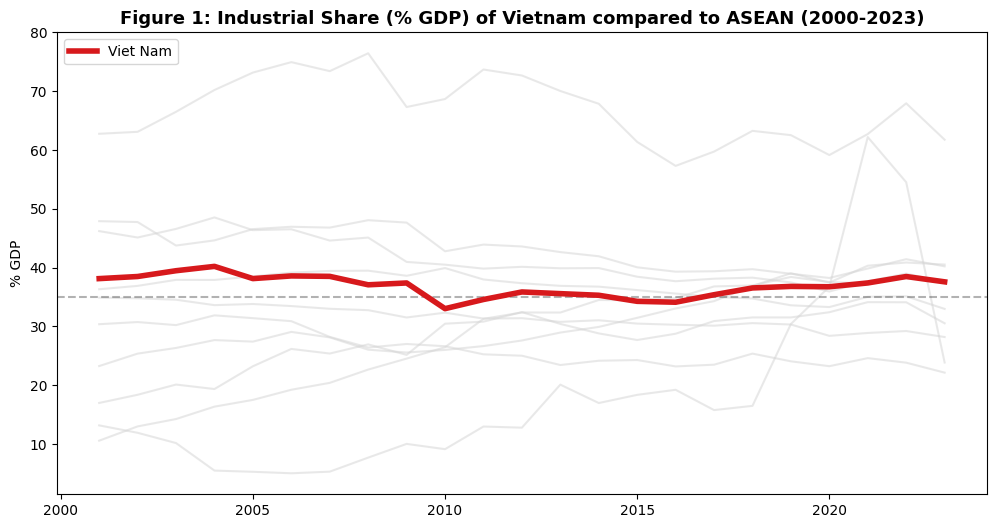

In [6]:
plt.figure(figsize=(12, 6))
for country in asean_all:
    if country in df_final['Country Name'].unique():
        color = '#D7191C' if country == 'Viet Nam' else 'lightgrey'
        alpha = 1.0 if country == 'Viet Nam' else 0.5
        linewidth = 4 if country == 'Viet Nam' else 1.5
        zorder = 10 if country == 'Viet Nam' else 1
        subset = df_final[df_final['Country Name'] == country]
        plt.plot(subset['Year'], subset['Ind_GDP'], color=color, linewidth=linewidth, alpha=alpha, zorder=zorder, label=country if country == 'Viet Nam' else "")

plt.axhline(35, color='black', linestyle='--', alpha=0.3)
plt.title("Figure 1: Industrial Share (% GDP) of Vietnam compared to ASEAN (2000-2023)", fontweight='bold', fontsize=13)
plt.ylabel("% GDP")
plt.legend(loc='upper left')
plt.show()

#### Data Explanation:
The data shows the contribution share of the industrial sector (including manufacturing, construction, mining) to the gross domestic product (GDP). The 35% dashed line represents the threshold of a highly industrialized economy.

#### In-depth Insights:
1. **Structural Divergence:** While ASEAN-4 economies (like Thailand, Indonesia) peaked their industrialization before 2010 and are trending downwards (early deindustrialization), Vietnam is the only country maintaining a stable growth trajectory.
2. **"Factory" Position:** Consistently anchoring above the 35% GDP mark confirms Vietnam is at the **Peak Industrialization** stage. This shows Vietnam's role as an important manufacturing link in the global value chain, but simultaneously forecasts immense emission pressure analyzed in subsequent steps.

### Question 2: Evaluating the Coupling between industrial output and Carbon emissions
- **Rationale for selection:** Verifying the Kuznets Curve theory. We need to know Vietnam's trajectory: Are emissions increasing positively with the economy or is there evidence of decoupling?
- **Metrics:** Combining `Ind_GDP` (% Industry) and `CO2_PC` ($CO_2$ emissions per capita - tons/person).

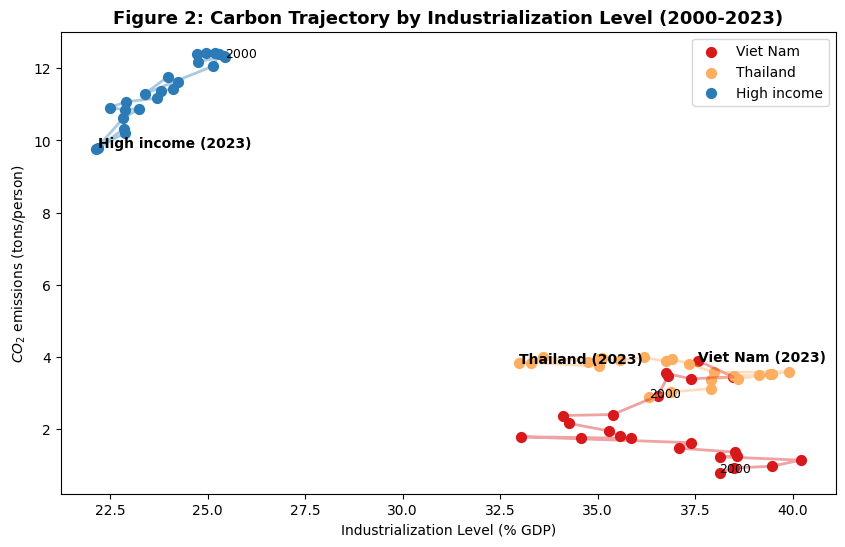

In [7]:
plt.figure(figsize=(10, 6))
targets = ['Viet Nam', 'Thailand', 'High income']
colors = {'Viet Nam': '#D7191C', 'Thailand': '#FDAE61', 'High income': '#2C7BB6'}

for country in targets:
    subset = df_final[df_final['Country Name'] == country].dropna(subset=['Ind_GDP', 'CO2_PC']).sort_values('Year')
    plt.plot(subset['Ind_GDP'], subset['CO2_PC'], color=colors[country], alpha=0.4, linewidth=2)
    plt.scatter(subset['Ind_GDP'], subset['CO2_PC'], color=colors[country], s=50, label=country)

    plt.text(subset['Ind_GDP'].iloc[0], subset['CO2_PC'].iloc[0], '2000', fontsize=9)
    plt.text(subset['Ind_GDP'].iloc[-1], subset['CO2_PC'].iloc[-1], f"{country} (2023)", fontweight='bold', fontsize=10)

plt.title("Figure 2: Carbon Trajectory by Industrialization Level (2000-2023)", fontweight='bold', fontsize=13)
plt.xlabel("Industrialization Level (% GDP)")
plt.ylabel("$CO_2$ emissions (tons/person)")
plt.legend()
plt.show()

#### Data Explanation:
The Trajectory chart connects annual data points. The horizontal axis is industrial scale, the vertical axis is carbon emissions. The direction of the line indicates the relationship between growth and pollution.

#### In-depth Insights:
1. **Phase 1 of the Kuznets Curve:** Vietnam's trajectory is a steep upward slope to the Northeast. This affirms Vietnam is firmly in **Phase 1 (Intensive phase)** of the Kuznets curve: industrial output increases entail corresponding increases in carbon emissions.
2. **Strong Coupling:** Unlike the **High Income** group (which has reached the decoupling point - moving leftwards), Vietnam has yet to optimize clean technology in production. Each unit of industrial GDP generated still carries a larger "carbon burden" each year.

### Question 3: Correlation between environmental degradation and public health resilience
- **Rationale for selection:** Deciphering the health paradox. Normally, increased air pollution reduces quality of life. The group wants to test whether Vietnam is successfully using economic benefits to offset environmental risks.
- **Metrics:** `PM25` ($PM_{2.5}$ concentration $\mu g/m^3$) and `Life_Exp` (Life expectancy at birth - years).

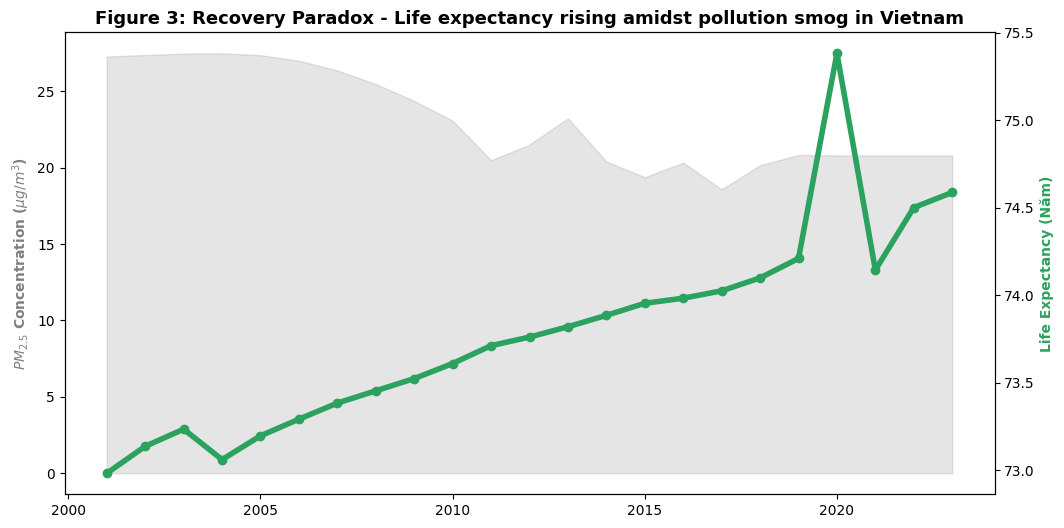

In [8]:
df_vn = df_final[df_final['Country Name'] == 'Viet Nam'].dropna(subset=['PM25', 'Life_Exp'])
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Trục 1: Vùng sương mù ô nhiễm (Area Chart)
ax1.fill_between(df_vn['Year'], df_vn['PM25'], color='grey', alpha=0.2, label='$PM_{2.5}$ Concentration')
# Trục 2: Thành quả tuổi thọ (Line Chart)
ax2.plot(df_vn['Year'], df_vn['Life_Exp'], color='#2CA25F', linewidth=4, marker='o', markersize=6, label='Life Expectancy')

ax1.set_ylabel("$PM_{2.5}$ Concentration ($\mu g/m^3$)", color='grey', fontweight='bold')
ax2.set_ylabel("Life Expectancy (Năm)", color='#2CA25F', fontweight='bold')
plt.title("Figure 3: Recovery Paradox - Life expectancy rising amidst pollution smog in Vietnam", fontweight='bold', fontsize=13)
plt.show()

#### Data Explanation:
The chart uses Dual-axis. The gray shaded area represents $PM_{2.5}$ fine dust pressure. The blue line shows the variation in the average life expectancy of Vietnamese people over two decades.

#### In-depth Insights:
1. **Contrasting trends:** Although $PM_{2.5}$ concentration in Vietnam remains at hazardous levels (around $20 \mu g/m^3$, double the WHO safe limit), average life expectancy has steadily increased from 73 to 75 years.
2. **Fiscal Space Hypothesis:** This serves as evidence for the **"Paying with social budget"** model. Profits accumulated from industrialization (question 1) have provided financial resources for the Government to invest in preventive healthcare, vaccines, and clean water. Current medical advances are temporarily "overcoming" the negative environmental impacts, but this is a fragile equilibrium that demands attention in the future.

## SUMMARY AND RECOMMENDATIONS
Data analysis for the 2000-2023 period shows Vietnam operating a **"High Input - High Output"** development model.
- Vietnam has the strongest industrial orientation in ASEAN, impressively improving life expectancy and basic quality of life for its people.
- However, this development is still reliant on "borrowing" environmental resources (Phase 1 EKC).
- **Recommendations:** To escape the middle-income trap sustainably like the High Income group, Vietnam must soon reach the "Turning point" by shifting towards renewable energy and gradually reducing GDP dependence on carbon-intensive industries.